# **Implementing Binary Classification using NumPy**

In [114]:
import numpy as np
import matplotlib.pyplot as plt

In [115]:
class LogisticRegression:
    def __init__(self, learning_rate=0.1, num_iterations=100):
        self.learning_rate = learning_rate
        self.num_iterations=num_iterations
        self.w = None
        self.b = None

    def initialize_parameters(self, num_fearures):
        self.w = np.zeros(num_fearures)
        self.b = 0

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def forward_pass(self, X):
        z = X @ self.w + b
        y_pred = self.sigmoid(z)
        return y_pred

    def cost(self, y, y_pred):
        return -np.mean(y * np.log(y_pred) - (1 - y) * np.log(1 - y_pred))

    def backward_pass(self, X, y, y_pred):
        m = X.shape[0]

        dw = np.mean((y_pred - y) @ X)
        db = np.mean(y_pred - y)

        return dw, db

    def update_parameters(self, dw, db):
        self.w = self.w - self.learning_rate * dw
        self.b = self.b - self.learning_rate * db

    def fit(self, X, y):
        self.initialize_parameters(X.shape[1])

        for _ in range(self.num_iterations):
            y_pred = self.forward_pass(X)
            loss = self.cost(y, y_pred)
            dw, db = self.backward_pass(X, y, y_pred)
            self.update_parameters(dw, db)

    def predict(self, X):
        y_pred = self.forward_pass(X)
        print(y_pred)
        return (y_pred >= 0.5).astype(int)

In [116]:
model = LogisticRegression()

In [117]:
model.fit(X, y)

In [118]:
model.predict(X)

[0.00180405 0.00920865 0.00920865 0.0456161  0.19730094 0.19730094
 0.86667349 0.86667349 0.97095452 0.99421665 0.99421665 0.99887014]


array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

In [49]:
X = np.array([
    [1, 1],
    [2, 1],
    [1, 2],
    [2, 2],
    [3, 2],
    [2, 3],
    [4, 3],
    [3, 4],
    [4, 4],
    [5, 4],
    [4, 5],
    [5, 5]
])

y = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

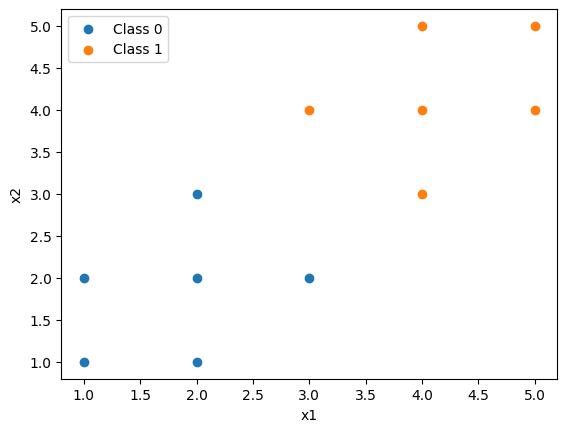

In [50]:
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

In [51]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [52]:
def model(X, w, b):
    z = X @ w + b
    return sigmoid(z)

In [53]:
w = np.zeros(X.shape[1])
b = 0

In [54]:
model(X, w, b)

array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

In [73]:
def dydw(X, y_pred, y):
    return np.mean((y_pred - y) @ X)

def dydb(X, y_pred, y):
    return np.mean((y_pred - y))

In [74]:
def train(w, b, X, y, learning_rate=0.1, num_iterations=1000):
    for _ in range(num_iterations):
        y_pred = model(X, w, b)
        w = w - learning_rate * dydw(X, y_pred, y)
        b = b - learning_rate * dydb(X, y_pred, y)
    return w, b

In [75]:
w, b = train(w, b, X, y)

In [76]:
def predict(X, w, b):
    probabilities = model(X, w, b)
    return (probabilities >= 0.5).astype(int)

In [77]:
predictions = predict(X, w, b)

In [78]:
print(predictions)
print(y)

[0 0 0 0 0 0 1 1 1 1 1 1]
[0 0 0 0 0 0 1 1 1 1 1 1]


In [68]:
X.shape

(12, 2)

In [72]:
np.zeros(X.shape[1]).shape

(2,)

In [113]:
y

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])